In [27]:
import numpy as np
import matplotlib.pyplot as plt

class LinearRegressionGD:
    def __init__(self, learning_rate=0.001, n_iters=100):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0.0
        self.theta_1 = 0.0
        self.sse_history = []

    def fit(self, X, y):
        m = len(y)
        for _ in range(self.n_iters):
            y_pred = self.theta_0 + self.theta_1 * X
            
            error = y_pred - y
            sse = np.sum(error ** 2)
            self.sse_history.append(sse)
            
            d_theta_0 = (2 / m) * np.sum(error)
            d_theta_1 = (2 / m) * np.sum(error * X)
    
            self.theta_0 -= self.learning_rate * d_theta_0
            self.theta_1 -= self.learning_rate * d_theta_1
    
    #  Bonus Task: إضافة دالة حساب MSE
    def calculate_mse(self, X, y):
        predictions = self.predict(X)
        return np.mean((y - predictions) ** 2)

    def predict(self, X):
        return self.theta_0 + self.theta_1 * X

    def plot_training(self, X, y):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        
        ax1.plot(self.sse_history)
        ax1.set_title("SSE over Iterations")
        ax1.set_xlabel("Iterations")
        ax1.set_ylabel("SSE")
        
        ax2.scatter(X, y, color='blue', label='Data Points')
        ax2.plot(X, self.predict(X), color='red', label='Regression Line')
        ax2.set_title("Linear Regression Fit")
        ax2.set_xlabel("X (House Size)")
        ax2.set_ylabel("y (Price)")
        ax2.legend()
        
        plt.tight_layout()
        plt.show()

In [8]:
X = np.array([50, 60, 70, 80, 90])
y = np.array([150, 180, 210, 240, 270])

model = LinearRegressionGD(learning_rate=0.0001, n_iters=100)
model.fit(X, y)

print(f"theta_0 (Intercept): {model.theta_0}")
print(f"theta_1 (Slope): {model.theta_1}")

theta_0 (Intercept): 0.04113676040970018
theta_1 (Slope): 2.999435373457505


In [9]:
x_new = np.array([70])
predicted_price = model.predict(x_new)

print(f"Predicted price for 70 m²: {predicted_price[0]:.2f}")

Predicted price for 70 m²: 210.00


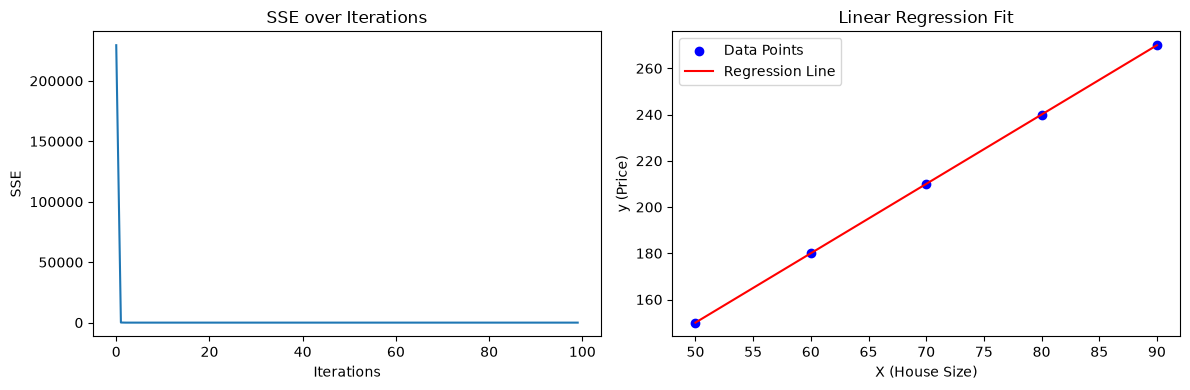

In [10]:
model.plot_training(X, y) 

Why SSE decreases over time: لأن الـ Gradient Descent بيعدّل الـ parameters theta_0 و theta_1 في كل step في اتجاه يقلل الـ cost function 

What convergence means: وصول الخوارزمية لنقطة الـ Minimum (أقل نسبة خطأ ممكنة) بحيث تغير القيم بعدها بيكون شبه معدوم.

C:\Users\11\AppData\Local\Temp\ipykernel_24000\2604853086.py:20: RuntimeWarning: overflow encountered in square
  sse = np.sum(error ** 2)


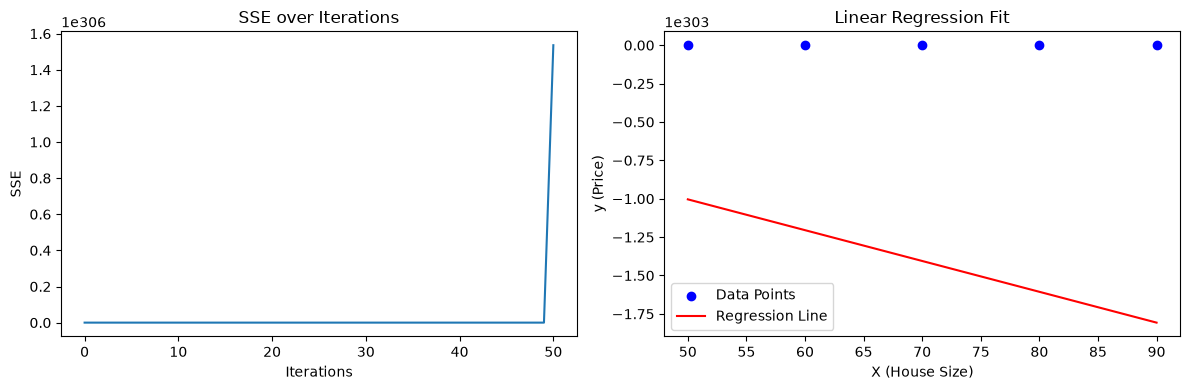

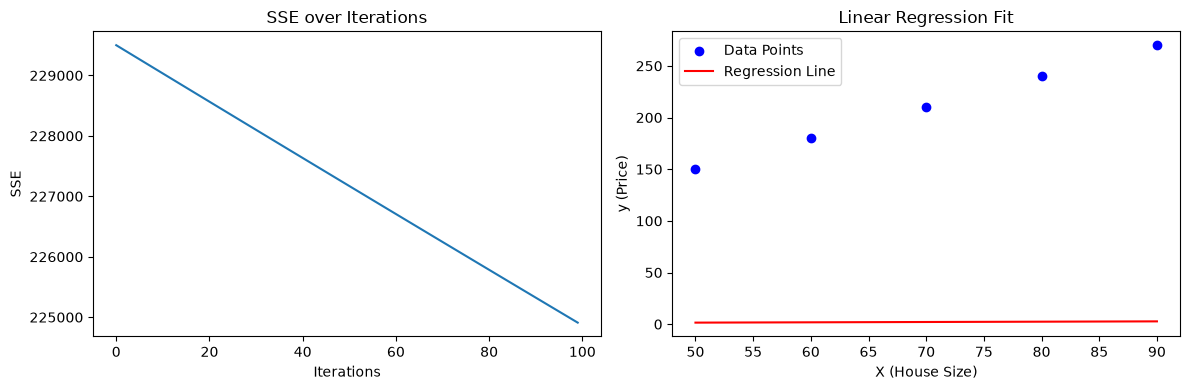

In [17]:
# 1. Very Large Learning Rate  0.1
model_large = LinearRegressionGD(learning_rate=0.1, n_iters=100)
model_large.fit(X, y)
model_large.plot_training(X, y)

# 2. Very Small Learning Rate 0.00000001
model_small = LinearRegressionGD(learning_rate=0.00000001, n_iters=100)
model_small.fit(X, y)
model_small.plot_training(X, y)

If learning rate is too large: بيحصل Divergence والـ SSE بيكبر بدلاً ما يقل (Overshooting)

If learning rate is too small: التقارب بيكون بطيء جداً وممكن نحتاج عدد Iterations كبير عشان نوصل للـ Minimum. 

In [31]:
model_large = LinearRegressionGD(learning_rate=0.005, n_iters=100)
model_large.fit(X, y)

model_small = LinearRegressionGD(learning_rate=0.000001, n_iters=100)
model_small.fit(X, y)

# حساب وطباعة MSE
model_large_mse = model_large.calculate_mse(X, y)
model_small_mse = model_small.calculate_mse(X, y)

C:\Users\11\AppData\Local\Temp\ipykernel_24000\1057348712.py:18: RuntimeWarning: overflow encountered in square
  sse = np.sum(error ** 2)
C:\Users\11\AppData\Local\Temp\ipykernel_24000\1057348712.py:30: RuntimeWarning: overflow encountered in square
  return np.mean((y - predictions) ** 2)


In [32]:
print(f"Large LR MSE: {model_large_mse:.2f}")
print(f"Small LR MSE: {model_small_mse:.2f}")

Large LR MSE: inf
Small LR MSE: 5903.83
